# 02 — TWFE DiD and Event Study

Baseline two-way fixed effects regression of unemployment on log(minimum wage), plus an event-study specification to check the parallel-trends assumption.

In [1]:
import sys
from pathlib import Path

# Walk up to the project root so the notebook runs from any working directory.
root = next(p for p in Path.cwd().resolve().parents if (p / "src").is_dir())
sys.path.insert(0, str(root))

# Data vintage: which raw inputs produced everything below. LAUS is
# revised, so an executed notebook has to carry its own provenance.
from src.data.manifest import format_manifest

print(format_manifest())


Data vintage recorded 2026-08-10T23:01:47+00:00
  BLS LAUS API v1, 2000-2022, measures unemployment_rate, labor_force
  Minimum wage source: Vaghul-Zipperer https://github.com/benzipperer/historicalminwage/releases/download/v1.4.0/mw_state_excel.zip
  bls_unemployment: d8a672e371b6... (110,329 bytes, modified 2026-08-10T22:58:45+00:00)
  user_minimum_wage_csv: absent
  vz_minimum_wage: 5176fbe0fe04... (1,022,044 bytes, modified 2026-07-26T01:22:57+00:00)


In [2]:
from src.data.loader import load_state_year_panel
from src.methods.twfe_did import estimate_twfe, summarize_twfe

panel, is_synthetic = load_state_year_panel()
result = estimate_twfe(panel)
print(result.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:      unemployment_rate   R-squared:                        0.0034
Estimator:                   PanelOLS   R-squared (Between):              0.3598
No. Observations:                1173   R-squared (Within):               0.0038
Date:                Mon, Aug 10 2026   R-squared (Overall):              0.3277
Time:                        19:31:46   Log-likelihood                   -1400.7
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      3.7357
Entities:                          51   P-value                           0.0535
Avg Obs:                       23.000   Distribution:                  F(1,1099)
Min Obs:                       23.000                                           
Max Obs:                       23.000   F-statistic (robust):             0.8910
                            

In [3]:
summarize_twfe(result)

,coef,std_error,pvalue,ci_lower,ci_upper
log_minimum_wage,0.575461,0.609635,0.345406,-0.62072,1.771641


## Event study

In [4]:
from src.methods.event_study import average_post_effect, estimate_event_study

# Never-treated states stay in the sample as the control group; always-treated
# states (no pre-period) are dropped. Without that, the leads and lags would be
# identified only by differential timing among treated states.
es_result, es_summary = estimate_event_study(panel)
print(f"{es_summary.attrs['n_adopters']} adopters, "
      f"{es_summary.attrs['n_never_treated']} never-treated controls, "
      f"{len(es_summary.attrs['always_treated_states'])} always-treated dropped")
es_summary

25 adopters, 15 never-treated controls, 11 always-treated dropped


,rel_time,coef,ci_lower,ci_upper
0,-5,0.028505,-0.291603,0.348613
1,-4,-0.072668,-0.361758,0.216422
2,-3,0.014942,-0.212832,0.242717
3,-2,-0.035116,-0.181157,0.110925
4,-1,0.000000,0.000000,0.000000
5,0,0.015808,-0.156975,0.188591
6,1,0.296407,0.014449,0.578365
7,2,0.372697,-0.150546,0.895939
8,3,0.648356,0.021012,1.275701
9,4,0.843186,0.157606,1.528765


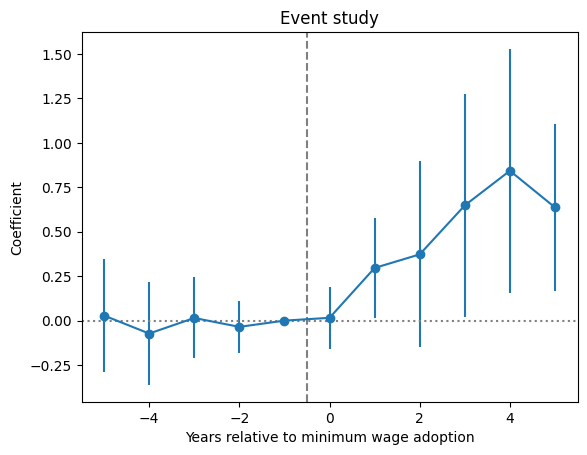

In [5]:
import matplotlib.pyplot as plt

plt.errorbar(es_summary.rel_time, es_summary.coef,
             yerr=[es_summary.coef - es_summary.ci_lower, es_summary.ci_upper - es_summary.coef],
             fmt='o-')
plt.axvline(-0.5, color='gray', linestyle='--')
plt.axhline(0, color='gray', linestyle=':')
plt.xlabel('Years relative to minimum wage adoption'); plt.ylabel('Coefficient')
plt.title('Event study'); plt.show()

## Pre-trend check

In [6]:
from src.diagnostics.parallel_trends import pretrend_joint_test

# A genuine joint Wald test over the lead coefficients, using the fitted
# state-clustered covariance matrix. Checking each lead's own CI one at a time
# is a screening pass, not a test -- it is carried along under
# 'individual_screen' to show which lead moves if the joint test rejects.
joint = pretrend_joint_test(es_result, es_summary)
print(f"leads tested:        {joint['leads_tested']}")
print(f"chi2({joint['df']}) = {joint['statistic']:.2f}, p = {joint['p_value']:.3f}")
print(f"no detectable pre-trend: {joint['passes']}")
print(f"individual screen:   {joint['individual_screen']}")

post = average_post_effect(es_result, es_summary)
print(f"\npost-period average: {post['estimate']:+.3f} "
      f"[{post['ci_lower']:+.3f}, {post['ci_upper']:+.3f}] (se {post['std_error']:.3f})")

leads tested:        [-5, -4, -3, -2]
chi2(4) = 3.70, p = 0.449
no detectable pre-trend: True
individual screen:   {'n_pre_periods': 4, 'n_significant_violations': 0, 'violating_periods': [], 'passes': True}

post-period average: +0.469 [+0.076, +0.862] (se 0.201)
